In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import random
import numpy as np
import os
import pandas as pd
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from torch.cuda.amp import GradScaler, autocast  # Para Mixed Precision Training
from tqdm import tqdm # Import tqdm for progress bar
import copy
from sklearn.model_selection import StratifiedKFold

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
def set_seed(seed):
    """
    Sets random seeds for reproducibility across different libraries and environments.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # Ensures consistent hash-based operations (e.g., dictionary order)

    torch.manual_seed(seed) # Set CPU seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)       # Set current GPU seed
        torch.cuda.manual_seed_all(seed)   # Set all GPUs seed if multiple are used

        # Ensure deterministic behavior for cuDNN backend (for convolutional operations)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False # Disable cuDNN autotuner to ensure determinism

        # For full PyTorch 1.8+ determinism (may impact performance and cause errors for some ops)
        # The CUBLAS_WORKSPACE_CONFIG variable is needed for certain CUDA ops to be deterministic.
        # It must be set *before* any CUDA context is created (usually done by the time this function runs).
        try:
            os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # Recommended for determinism with CuBLAS >= 10.2
            torch.use_deterministic_algorithms(True)
        except RuntimeError as e:
            # This can happen on older PyTorch versions or if deterministic algorithms cannot be used
            # for a specific operation.
            print(f"Warning: Could not set deterministic algorithms. Error: {e}")
            print("Some PyTorch operations might still be non-deterministic. Consider reviewing PyTorch version and operation types.")
            # If determinism is critical, you might want to stop execution or investigate further.

set_seed(42)

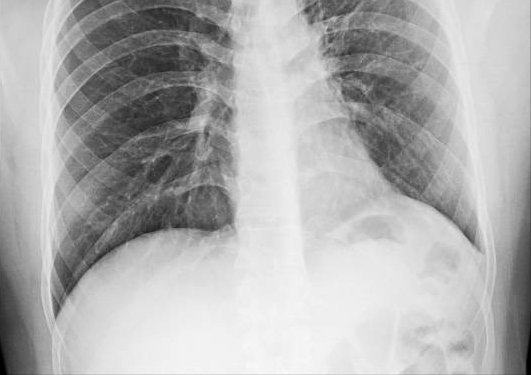

In [4]:
caminho_imagem = "D:/iniciacao_cientifica/untreated_images/images/Entry_ROI/img525.png"
imagem = Image.open(caminho_imagem)
display(imagem)

In [5]:
# Define the specific directory where all the relevant images are located
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\untreated_images\data\Data_Entry_Undergrad_PNG.csv"

# Reading the CSV file
all_xray_df = pd.read_csv(csv_path)

# Create a dictionary to map image filenames (from CSV) to their full file paths.
# We assume the 'Image Label' column in the CSV contains just the filename (e.g., 'img525.png').
all_image_paths_map = {}
# Use glob to find all PNGs *directly within* the specified Entry_ROI directory
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # The key for the dictionary should be just the filename, to match the 'Image Label' column
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

# Printing the number of actual image files found and total rows in the DataFrame
print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV:', all_xray_df.shape[0])

# Mapping the full image paths to the 'Image Label' column in the DataFrame.
# We are using .get() to safely handle cases where an image label from the CSV might not be found.
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# --- Crucial check for unmapped paths ---
# It's important to verify if all entries in your CSV found a corresponding image file.
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"Warning: {unmapped_images_count} images in the CSV could not be mapped to a file path "
          f"from '{image_entry_roi_dir}'. These rows will have 'path' as NaN.")
    # Option: Display a few unmapped entries to debug
    # print("\nSample unmapped CSV entries:")
    # display(all_xray_df[all_xray_df['path'].isnull()].head())
    
    # Option: Remove unmapped rows if they are not needed for further analysis
    # all_xray_df.dropna(subset=['path'], inplace=True)
    # print(f"Removed {unmapped_images_count} unmapped entries. Remaining rows: {len(all_xray_df)}")
else:
    print("All CSV entries successfully mapped to image file paths.")

# Displaying a sample of 3 rows from the DataFrame, now including the new 'path' column
display(all_xray_df.sample(3))

Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV: 1072


,Image Label,Finding Labels,Other,path
992,img993.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...
746,img747.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...
1066,img1067.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...



Sample of DataFrame with 'path' and 'is_tb' columns:


,Image Label,Finding Labels,path,is_tb
594,img595.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
703,img704.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
889,img890.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
306,img307.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
685,img686.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_6068\765781757.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values[:len(tb_categories)], ax=ax1, palette="viridis") # Slicing for safety


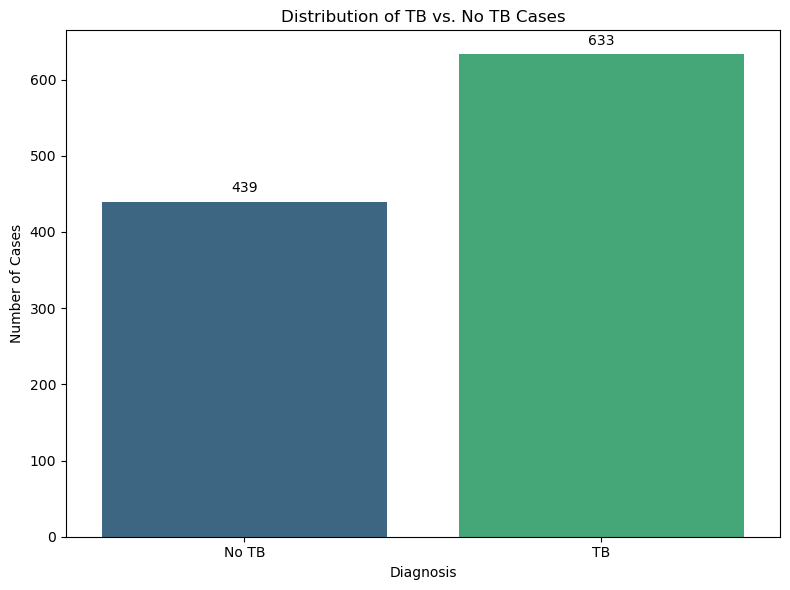

In [6]:
# Assuming all_xray_df with the 'path' column is already in memory from the previous cell.

# --- SIMPLIFIED 'is_tb' LABEL CREATION ---
# Given the clarification: The only finding labels are "No Findings" and "TB".
# Therefore, we can directly map 'TB' to 1 and 'No Findings' to 0.
# This makes the conversion explicit and robust for these two exact strings.
mapping_dict = {'TB': 1, 'No Findings': 0}
all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)
# It's good practice to ensure no NaNs in 'is_tb' if these are the *only* values
if all_xray_df['is_tb'].isnull().any():
    print(f"Critical Warning: Unexpected 'Finding Labels' found that are neither 'TB' nor 'No Findings'.")
    print("Unique unexpected labels:", all_xray_df[all_xray_df['is_tb'].isnull()]['Finding Labels'].unique())
    # Depending on the severity, you might want to stop execution or drop these rows.
    # For now, we'll continue but be aware.

# Display a sample of the DataFrame to show the new 'path' and 'is_tb' columns
print("\nSample of DataFrame with 'path' and 'is_tb' columns:")
display(all_xray_df[['Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

# --- PLOTTING THE DISTRIBUTION OF THE NEW 'is_tb' LABEL ---
# This plot directly shows the primary classification target (TB vs. No TB),
# which is what your model will learn to predict.
tb_label_counts = all_xray_df['is_tb'].value_counts().sort_index()
# Prepare data for plotting, ensuring both 0 and 1 are accounted for
tb_categories = ['No TB', 'TB']
# Use .get(key, default_value) to safely retrieve counts, in case one category has zero entries.
tb_values = [tb_label_counts.get(0, 0), tb_label_counts.get(1, 0)]
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
sns.barplot(x=tb_categories, y=tb_values[:len(tb_categories)], ax=ax1, palette="viridis") # Slicing for safety
ax1.set_title('Distribution of TB vs. No TB Cases')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')
# Add exact counts on top of bars for clarity
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_6068\1128706670.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")



Original class counts (0: No TB, 1: TB):
is_tb
1    633
0    439
Name: count, dtype: int64

Minority class 'No TB (0)' count: 439
Undersampling majority class 'TB (1)' to match minority count.

Balanced class counts (0: No TB, 1: TB):
is_tb
1    439
0    439
Name: count, dtype: int64


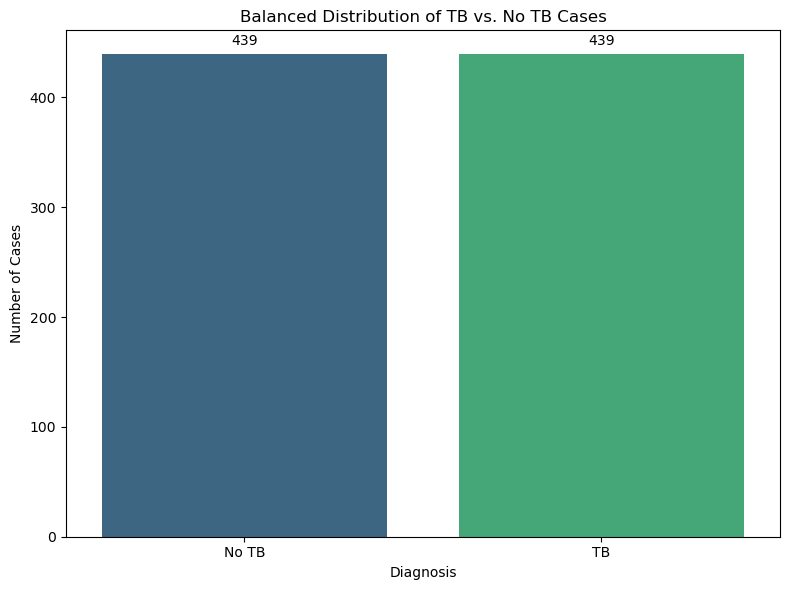


Sample of Balanced DataFrame:


,Image Label,Finding Labels,path,is_tb
194,img969.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
785,img347.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
616,img178.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
811,img373.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
706,img268.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0


In [7]:
# Assuming all_xray_df (with 'path' and 'is_tb' columns) is already in memory from previous cells.

# Display original class counts based on the 'is_tb' column (useful before balancing)
original_counts = all_xray_df['is_tb'].value_counts()
print("\nOriginal class counts (0: No TB, 1: TB):")
print(original_counts)

# --- Class Balancing: Undersampling the Majority Class ---
# Separate the two classes based on the 'is_tb' column
no_tb_df = all_xray_df[all_xray_df['is_tb'] == 0]
tb_df = all_xray_df[all_xray_df['is_tb'] == 1]

# Determine which class is majority and minority
if len(no_tb_df) > len(tb_df):
    majority_df = no_tb_df
    minority_df = tb_df
    majority_label = 'No TB (0)'
    minority_label = 'TB (1)'
else: # If TB is majority or counts are equal
    majority_df = tb_df
    minority_df = no_tb_df
    majority_label = 'TB (1)'
    minority_label = 'No TB (0)'

# Count of the minority class (this is the target count for both classes after balancing)
minority_count = len(minority_df)
print(f"\nMinority class '{minority_label}' count: {minority_count}")
print(f"Undersampling majority class '{majority_label}' to match minority count.")

# Resample the majority class to match the minority count (undersampling)
majority_resampled_df = majority_df.sample(n=minority_count, random_state=42)

# Combine the resampled majority rows with the minority rows (which are kept entirely)
balanced_df = pd.concat([majority_resampled_df, minority_df]).reset_index(drop=True)

# Verify the new class counts
balanced_counts = balanced_df['is_tb'].value_counts()
print("\nBalanced class counts (0: No TB, 1: TB):")
print(balanced_counts)

# --- Plotting the Balanced Dataset (displayed in notebook) ---
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
# Prepare data for plotting, ensuring both 0 and 1 are accounted for
tb_categories = ['No TB', 'TB']
# Use .get(key, default_value) to safely retrieve counts, in case a category has zero entries.
tb_values = [balanced_counts.get(0, 0), balanced_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")
ax1.set_title('Balanced Distribution of TB vs. No TB Cases')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')
# Add exact counts on top of bars for clarity
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show() # Display the plot in the Jupyter Notebook

# Display a sample of the balanced DataFrame
print("\nSample of Balanced DataFrame:")
display(balanced_df[['Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

In [8]:
print("Initial class distribution in balanced_df:")
print(balanced_df['is_tb'].value_counts())

# --- Step 1: Split off a final, independent Test Set ---
# We'll set aside a portion (e.g., 10-20%) of the balanced_df to be our final test set.
# The remaining data will be used for K-Fold Cross-Validation.

# Let's aim for 10% for the final test set for now.
# The remaining 90% will be used for the K-fold training and validation.
data_for_kfold, final_test_df = train_test_split(
    balanced_df,
    test_size=0.1,  # 10% for the final test set
    stratify=balanced_df['is_tb'],  # Maintain class balance
    random_state=42 # Ensure reproducibility
)

print("\nFinal Test Set created:")
print(f"Size: {len(final_test_df)}")
print(final_test_df['is_tb'].value_counts())

print("\nData remaining for K-Fold Cross-Validation:")
print(f"Size: {len(data_for_kfold)}")
print(data_for_kfold['is_tb'].value_counts()) # This will be the new 'balanced_df' for K-fold

print("\nTest set has been successfully created and is in memory. The rest of the data is ready for K-Fold.")

Initial class distribution in balanced_df:
is_tb
1    439
0    439
Name: count, dtype: int64

Final Test Set created:
Size: 88
is_tb
1    44
0    44
Name: count, dtype: int64

Data remaining for K-Fold Cross-Validation:
Size: 790
is_tb
0    395
1    395
Name: count, dtype: int64

Test set has been successfully created and is in memory. The rest of the data is ready for K-Fold.


Visualizing class distributions for K-Fold data and the Final Test Set:


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_6068\3965805983.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=kfold_data_values, ax=axes[0], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_6068\3965805983.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=final_test_values, ax=axes[1], palette=colors)


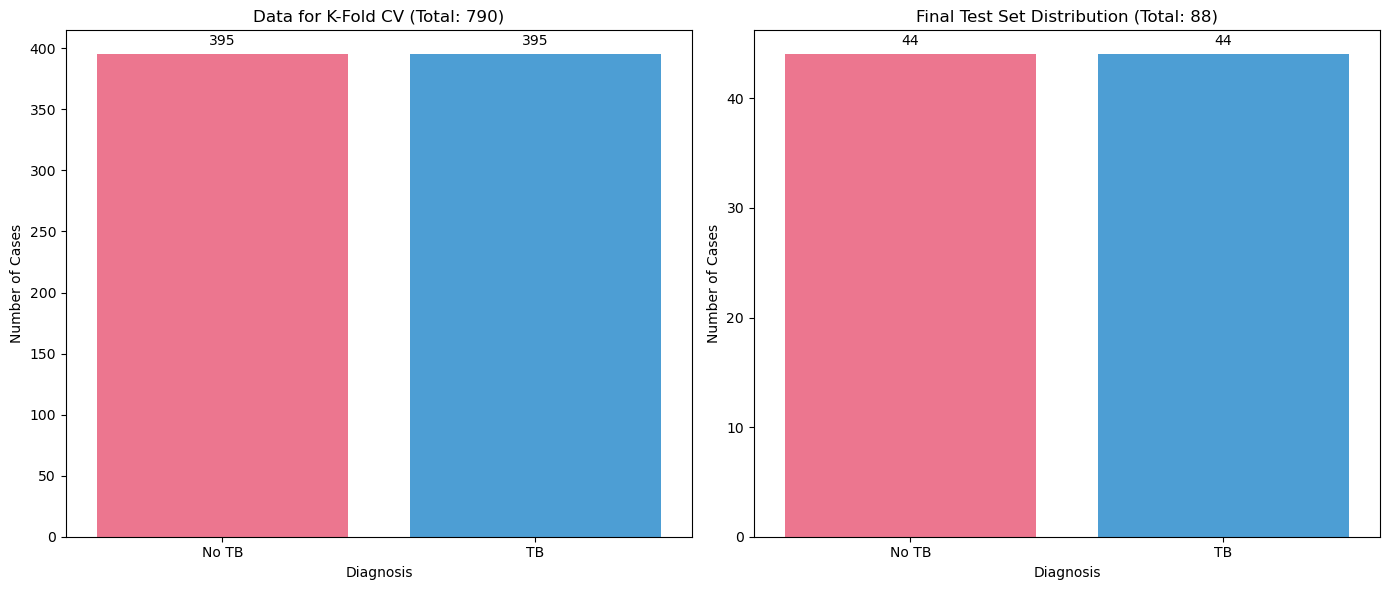

In [9]:
print("Visualizing class distributions for K-Fold data and the Final Test Set:")

# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Adjust figsize as needed

# Define common properties for categories and colors
tb_categories = ['No TB', 'TB']
colors = ['#FF6384', '#36A2EB']


# --- Plot for Data for K-Fold Cross-Validation ---
kfold_data_counts = data_for_kfold['is_tb'].value_counts().sort_index()
kfold_data_values = [kfold_data_counts.get(0, 0), kfold_data_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=kfold_data_values, ax=axes[0], palette=colors)
axes[0].set_title(f'Data for K-Fold CV (Total: {len(data_for_kfold)})')
axes[0].set_ylabel('Number of Cases')
axes[0].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')


# --- Plot for Final Test Set ---
final_test_counts = final_test_df['is_tb'].value_counts().sort_index()
final_test_values = [final_test_counts.get(0, 0), final_test_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=final_test_values, ax=axes[1], palette=colors)
axes[1].set_title(f'Final Test Set Distribution (Total: {len(final_test_df)})')
axes[1].set_ylabel('Number of Cases')
axes[1].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show() # Display the plots directly in the Jupyter Notebook output

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np # Ensure numpy is imported for np.nan checks
import os
from PIL import Image
from torchvision import transforms
from tqdm.notebook import tqdm # Import tqdm for progress bar

# --- Define the custom dataset class (adapted for your DataFrame) ---
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): DataFrame with columns 'path' and 'is_tb'.
            transform (callable, optional): Transformations to be applied to the images.
        """
        self.dataframe = dataframe
        self.transform = transform
        # Verify the integrity of image paths right after initialization
        self.dataframe = self._validate_image_paths()
    def _validate_image_paths(self):
        """
        Removes entries with invalid image paths.
        Uses pandas.Series.apply for more efficient checking and boolean indexing for filtering.
        """
        initial_count = len(self.dataframe)
        
        # Create a boolean mask indicating which paths exist and are strings
        # CRITICAL ADDITION: Ensure path is a string before calling os.path.exists
        valid_paths_mask = self.dataframe['path'].apply(lambda x: isinstance(x, str) and os.path.exists(x))
        
        # Log warnings for missing images AND invalid types
        invalid_paths_df = self.dataframe.loc[~valid_paths_mask]
        if not invalid_paths_df.empty:
            print(f"Warning: {len(invalid_paths_df)} images not found or had invalid path types. Examples:")
            for img_path_val in invalid_paths_df['path'].head(5): # Print only first 5 warnings
                print(f"  - {img_path_val} (Type: {type(img_path_val)})")
            
        validated_dataframe = self.dataframe[valid_paths_mask].reset_index(drop=True)
        
        if len(validated_dataframe) == 0:
            raise ValueError("No valid images found in the DataFrame after path validation.")
        
        if len(validated_dataframe) < initial_count:
            print(f"Dataset reduced from {initial_count} to {len(validated_dataframe)} valid images.")
            
        return validated_dataframe
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        try:
            # Check if path is valid before opening (double-check after _validate_image_paths)
            if not isinstance(img_path, str) or not os.path.exists(img_path):
                raise FileNotFoundError(f"Path is not a valid string or does not exist: {img_path}")

            # Open the image lazily (pixel data not loaded yet)
            image = Image.open(img_path)
            # --- CRITICAL FIX FOR MEMORYERROR ---
            max_preliminary_dim = 512 
            if image.size[0] > max_preliminary_dim or image.size[1] > max_preliminary_dim:
                if image.size[0] > image.size[1]:
                    new_width = max_preliminary_dim
                    new_height = int(max_preliminary_dim * image.size[1] / image.size[0])
                else:
                    new_height = max_preliminary_dim
                    new_width = int(max_preliminary_dim * image.size[0] / image.size[1])
                image = image.resize((new_width, new_height), Image.LANCZOS)
            # --- END CRITICAL FIX ---
            image = image.convert('RGB')
            label = self.dataframe.iloc[idx]['is_tb']
            label = torch.tensor(label, dtype=torch.float32)
            
            if self.transform:
                image = self.transform(image)
                
            return image, label
        except Exception as e:
            raise RuntimeError(f"Error loading or processing image {img_path} at index {idx}: {e}") from e
# Function to compute dataset statistics (global mean and std) - Unchanged from previous version
def compute_dataset_stats(loader):
    """
    Computes the global pixel-wise mean and standard deviation for normalization
    across all images in the dataset, per channel.
    """
    total_pixels = torch.zeros(3)
    sum_pixel_values = torch.zeros(3)
    sum_squared_pixel_values = torch.zeros(3)
    print("Calculating dataset mean and std for k-fold data...")
    for i, (images, _) in enumerate(tqdm(loader, desc="Calculating Stats")):
        if images is None or images.numel() == 0 or images.dim() != 4:
            print(f"Skipping empty or invalid batch {i}.")
            continue
            
        images_flat = images.view(images.size(0), images.size(1), -1)
        sum_pixel_values += images_flat.sum(dim=[0, 2])
        sum_squared_pixel_values += (images_flat ** 2).sum(dim=[0, 2])
        
        total_pixels += images_flat.size(0) * images_flat.size(2)
    if total_pixels.sum() == 0:
        raise ValueError("No valid image data processed to compute statistics.")
    mean = sum_pixel_values / total_pixels
    variance = (sum_squared_pixel_values / total_pixels) - (mean ** 2)
    std = torch.sqrt(torch.clamp(variance, min=0.0))
    
    return mean, std

# --- Main execution block for computing global stats ---
# Ensure 'data_for_kfold' is pre-loaded and accessible.
if 'data_for_kfold' not in locals():
    print("Error: 'data_for_kfold' not found in memory. Please ensure previous data splitting steps were run.")
    raise NameError("'data_for_kfold' not found. It should be in memory from previous steps.")

# CRITICAL FIX: Explicitly ensure no None/NaN in 'path' before creating the dataset
print("\n--- Performing final check and cleaning of 'path' column in data_for_kfold before dataset creation ---")
initial_data_for_kfold_count = len(data_for_kfold)
data_for_kfold.dropna(subset=['path'], inplace=True) # Drops rows where 'path' is NaN/None
# Also remove rows where path might be an empty string or non-string after dropna
data_for_kfold = data_for_kfold[data_for_kfold['path'].apply(lambda x: isinstance(x, str) and x.strip() != '')]
data_for_kfold.reset_index(drop=True, inplace=True)
cleaned_count = len(data_for_kfold)

if cleaned_count < initial_data_for_kfold_count:
    print(f"Cleaned {initial_data_for_kfold_count - cleaned_count} rows with invalid paths from data_for_kfold.")
    print(f"New size of data_for_kfold: {cleaned_count}")
if cleaned_count == 0:
    raise ValueError("data_for_kfold is empty after cleaning invalid paths. Cannot compute stats.")
print("--- 'path' column check complete ---")


temp_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
try:
    print(f"\nAttempting to compute stats on {len(data_for_kfold)} images in 'data_for_kfold'.")
    temp_dataset_for_stats = ChestXRayDataset(dataframe=data_for_kfold, transform=temp_transforms)
    
    temp_loader_for_stats = DataLoader(
        temp_dataset_for_stats,
        batch_size=32,
        shuffle=False,
        num_workers=0
    )
    
    global_dataset_mean, global_dataset_std = compute_dataset_stats(temp_loader_for_stats)
    
    print("\n--- Computed Global Dataset Statistics for K-Fold Data ---")
    print(f"Mean (RGB channel-wise):     {global_dataset_mean.tolist()}")
    print(f"Standard Dev (RGB channel-wise): {global_dataset_std.tolist()}")
    print("---------------------------------------------------------")
    
except Exception as e:
    print(f"An error occurred during dataset stats computation: {e}")


--- Performing final check and cleaning of 'path' column in data_for_kfold before dataset creation ---
Cleaned 2 rows with invalid paths from data_for_kfold.
New size of data_for_kfold: 788
--- 'path' column check complete ---

Attempting to compute stats on 788 images in 'data_for_kfold'.
Calculating dataset mean and std for k-fold data...


Calculating Stats:   0%|          | 0/25 [00:00<?, ?it/s]


--- Computed Global Dataset Statistics for K-Fold Data ---
Mean (RGB channel-wise):     [0.5882002115249634, 0.5882002115249634, 0.5882002115249634]
Standard Dev (RGB channel-wise): [0.2599307894706726, 0.2599307894706726, 0.2599307894706726]
---------------------------------------------------------


In [11]:
print(f"Using computed mean for normalization: {global_dataset_mean.tolist()}")
print(f"Using computed std for normalization: {global_dataset_std.tolist()}")

# 1. Training Transforms (with Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.RandomHorizontalFlip(),        # Randomly flip images horizontally
    transforms.RandomRotation(10),            # Randomly rotate images by +/- 10 degrees
    transforms.ColorJitter(                   # Randomly change brightness, contrast, saturation, hue
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.1
    ),
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

# 2. Validation and Test Transforms (no Data Augmentation)
# These should be deterministic to ensure consistent evaluation.
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

print("\nFinal image transformation pipelines defined:")
print("  - train_transforms (includes data augmentation)")
print("  - val_test_transforms (for validation and test sets)")

Using computed mean for normalization: [0.5882002115249634, 0.5882002115249634, 0.5882002115249634]
Using computed std for normalization: [0.2599307894706726, 0.2599307894706726, 0.2599307894706726]

Final image transformation pipelines defined:
  - train_transforms (includes data augmentation)
  - val_test_transforms (for validation and test sets)


In [12]:
def define_model(num_classes=1, freeze_pretrained=True):
    """
    Defines and customizes a pre-trained ResNet50 model for binary classification.

    Args:
        num_classes (int): The number of output classes. For binary classification, typically 1.
        freeze_pretrained (bool): If True, freezes the parameters of the pre-trained layers.
                                  Only the new classification head will be trained.
    Returns:
        torch.nn.Module: The configured ResNet50 model.
    """
    print("Loading pre-trained ResNet50 model for fold...") # This will print for each fold
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    if freeze_pretrained:
        for param in model.parameters():
            param.requires_grad = False

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device) # Ensure 'device' is accessible
    return model

In [13]:
import time
import copy
from tqdm.notebook import tqdm
import os
import torch
import torch.nn as nn
import math # <--- ADD THIS IMPORT FOR math.isnan()

# --- Global Constants for K-Fold and Training ---
K_FOLDS = 5 # Number of folds for cross-validation
BATCH_SIZE = 32
NUM_WORKERS = 0 # Set to 0 for Windows compatibility; for performance on non-Windows set > 0
NUM_EPOCHS = 50 # Increased epochs, early stopping will manage actual run time
PATIENCE = 10 # Number of epochs to wait for improvement before stopping

# --- Device Configuration (ensure 'device' is already defined or define here if running standalone) ---
# For example: device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- Model Definition (copied from previous successful snippet) ---
# This function should be defined ONCE before the training loop
# No changes here, it is just included for completeness but should exist in your notebook earlier.
# def define_model(num_classes=1, freeze_pretrained=True):
#     print("Loading pre-trained ResNet50 model for fold...")
#     model = resnet50(weights=ResNet50_Weights.DEFAULT)
#     if freeze_pretrained:
#         for param in model.parameters():
#             param.requires_grad = False
#     num_ftrs = model.fc.in_features
#     model.fc = nn.Linear(num_ftrs, num_classes)
#     model = model.to(device)
#     return model

# --- Training Loop Function (train_model_kfold) ---
def train_model_kfold(model, criterion, optimizer, scheduler, train_loader, val_loader,
                      num_epochs, device, fold_idx, patience,
                      current_best_val_accuracy, best_model_wts_overall):
    """
    Trains and validates the PyTorch model for a single fold, with early stopping.

    Args:
        model (torch.nn.Module): The model to train.
        criterion (torch.nn.Module): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer.
        scheduler (torch.optim.lr_scheduler._LRScheduler): The learning rate scheduler.
        train_loader (DataLoader): DataLoader for the training set.
        val_loader (DataLoader): DataLoader for the validation set.
        num_epochs (int): Max number of epochs to train for.
        device (torch.device): The device (CPU or CUDA) to use for training.
        fold_idx (int): Current fold number for logging.
        patience (int): Number of epochs to wait for validation loss improvement before stopping.
        current_best_val_accuracy (float): Best accuracy achieved across all previous folds, for saving best model.
        best_model_wts_overall (dict): Weights of the best model across all folds.

    Returns:
        tuple: A tuple containing:
            - dict: Metric history for this fold.
            - float: Best validation accuracy achieved in this fold.
            - dict: Updated best model weights if this fold yields a new overall best.
    """
    since = time.time()

    best_fold_val_accuracy = 0.0
    best_fold_model_wts = copy.deepcopy(model.state_dict())

    # Early stopping variables
    epochs_no_improve = 0
    min_val_loss = float('inf') # Track minimum validation loss for early stopping

    # Initialize GradScaler for mixed precision training (if CUDA is available)
    scaler = None
    if device.type == 'cuda':
        # FIXED: Use torch.amp.GradScaler as per FutureWarning
        scaler = torch.amp.GradScaler('cuda')
        print("Mixed precision training enabled (using GradScaler).")
    else:
        print("Mixed precision training not enabled (not using CUDA).")


    print(f"\n--- Starting training for Fold {fold_idx+1} ---\n")
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} (Fold {fold_idx+1})')
        print('-' * 20)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            # Iterate over data with a progress bar
            # CORRECTED: Added enumerate(tqdm(...)) to define 'i'
            for i, (inputs, labels) in enumerate(tqdm(dataloader, desc=f"{phase} Phase E{epoch+1}")):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients for THIS BATCH
                optimizer.zero_grad()

                # Corrected Forward pass and loss calculation with autocast/no_grad context
                with torch.amp.autocast(device_type='cuda', enabled=(phase == 'train' and device.type == 'cuda')) if scaler else torch.no_grad():
                    outputs = model(inputs)
                    if labels.dim() == 1:
                        labels = labels.unsqueeze(1)
                    loss = criterion(outputs, labels)

                # Backward + optimize only if in training phase
                if phase == 'train':
                    if scaler: # Use GradScaler for mixed precision
                        scaler.scale(loss).backward()
                        # Add gradient clipping to prevent exploding gradients
                        scaler.unscale_(optimizer) # Must unscale before clipping
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Clip gradients L2 norm to 1.0
                        scaler.step(optimizer)
                        scaler.update()
                    else: # Standard backpropagation for non-CUDA or if scaler not used
                        loss.backward()
                        # Add gradient clipping for non-mixed precision
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                # Convert logits to probabilities and then to binary predictions for metrics
                preds_proba = torch.sigmoid(outputs)
                binary_preds = (preds_proba > 0.5).float() # Threshold at 0.5

                # Statistics accumulation for THIS BATCH
                # Use .item() safely after checking if loss is NaN.
                if torch.isnan(loss):
                    print(f"Warning: NaN loss encountered in {phase} phase, batch {i+1} of Fold {fold_idx+1} Epoch {epoch+1}. Skipping batch loss accumulation.")
                    # If you wish to stop training on first NaN loss, you can raise an error here.
                    # Or, better, just don't add this corrupted loss to running_loss.
                else:
                    running_loss += loss.item() * inputs.size(0)

                # Accuracy calculation based on predictions
                running_corrects += torch.sum(binary_preds == labels.data)
                
                # Collect all predictions and labels for phase-end metrics calculation
                all_preds.extend(binary_preds.view(-1).cpu().numpy())
                all_labels.extend(labels.view(-1).cpu().numpy())
            # End of batch loop for the current phase

            # Calculate epoch statistics (based on accumulated running_* values)
            # Add check for dataloader.dataset length to prevent division by zero potential if dataset became empty
            if len(dataloader.dataset) > 0:
                epoch_loss = running_loss / len(dataloader.dataset)
                epoch_acc = running_corrects.double() / len(dataloader.dataset)
            else: # If dataloader.dataset is empty (shouldn't happen with our checks)
                epoch_loss = float('nan')
                epoch_acc = 0.0

            # Store metrics in history and handle scheduler step
            if phase == 'train':
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            else: # Validation phase
                from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
                # Protect against all_labels/all_preds being empty if dataloader.dataset was 0
                if len(all_labels) == 0:
                    val_accuracy = 0.0
                    val_precision = 0.0
                    val_recall = 0.0
                    val_f1 = 0.0
                else:
                    val_accuracy = accuracy_score(all_labels, all_preds)
                    val_precision = precision_score(all_labels, all_preds, zero_division=0)
                    val_recall = recall_score(all_labels, all_preds, zero_division=0)
                    val_f1 = f1_score(all_labels, all_preds, zero_division=0)

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} (sklearn: {val_accuracy:.4f})')
                print(f'   Precision: {val_precision:.4f} Recall: {val_recall:.4f} F1-Score: {val_f1:.4f}')

                # Early stopping logic (based on validation loss)
                # If epoch_loss is NaN, min_val_loss remains inf, and early stopping is not triggered by improvement.
                # However, if loss is NaN, it's a critical failure and early stopping might trigger based on patience.
                if not torch.isnan(epoch_loss) and epoch_loss < min_val_loss:
                    min_val_loss = epoch_loss
                    epochs_no_improve = 0
                    best_fold_val_accuracy = val_accuracy # Update best accuracy for this fold (from non-loss metrics)
                    best_fold_model_wts = copy.deepcopy(model.state_dict()) # Save best model for this fold
                    
                    # Also check if this is the overall best model across all folds so far
                    if val_accuracy > current_best_val_accuracy:
                        current_best_val_accuracy = val_accuracy
                        best_model_wts_overall = copy.deepcopy(model.state_dict())
                        print(f'   -> New overall best validation accuracy: {current_best_val_accuracy:.4f}. Overall best model weights updated.')
                else:
                    epochs_no_improve += 1
                    print(f'   Validation loss did not improve (or was NaN). Epochs without improvement: {epochs_no_improve}/{patience}')

        print() # Newline after each epoch

        # Step the scheduler at the end of each epoch, after both train and val phases
        scheduler.step()

        # Check for early stopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs due to no improvement for {patience} epochs.')
            break # Exit epoch loop

    time_elapsed = time.time() - since
    print(f'Fold {fold_idx+1} training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Fold {fold_idx+1} Val Accuracy: {best_fold_val_accuracy:.4f}')

    # Load best model weights for this fold before returning
    model.load_state_dict(best_fold_model_wts)
    return {
        'val_accuracy': best_fold_val_accuracy,
        'val_loss': min_val_loss,
        'val_precision': val_precision, # Returns metrics from the epoch with the best loss, not necessarily highest score for metrics
        'val_recall': val_recall,       # If high values are needed, make sure to store metrics with best_fold_val_accuracy epoch
        'val_f1': val_f1
    }, current_best_val_accuracy, best_model_wts_overall



# --- K-Fold Cross-Validation Main Orchestration ---
# Ensure these imports are available from previous cells
from sklearn.model_selection import StratifiedKFold

# Ensure 'data_for_kfold' DataFrame is pre-loaded and accessible.
# Ensure 'global_dataset_mean' and 'global_dataset_std' are pre-computed.
# Ensure 'train_transforms' and 'val_test_transforms' are defined.
# Ensure 'define_model' is defined.
# Ensure 'evaluate_model' (for final test) is defined.


skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Lists to store results from each fold
fold_results = []
metrics_per_fold = {
    'val_accuracy': [], 'val_loss': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}

best_overall_val_accuracy = 0.0
# This 'best_overall_model_wts' will be the state_dict of the one model
# that achieved the highest validation accuracy across ALL folds.
best_overall_model_wts = None 

for fold_idx, (train_index, val_index) in enumerate(skf.split(data_for_kfold, data_for_kfold['is_tb'])):
    print(f"\n====================================")
    print(f"       Starting Fold {fold_idx+1}/{K_FOLDS}      ")
    print(f"====================================")

    # 1. Create DataFrames for the current fold
    train_df_fold = data_for_kfold.iloc[train_index].reset_index(drop=True)
    val_df_fold = data_for_kfold.iloc[val_index].reset_index(drop=True)

    print(f"Fold {fold_idx+1} Train size: {len(train_df_fold)} images")
    print(f"Fold {fold_idx+1} Validation size: {len(val_df_fold)} images")

    # 2. Instantiate Datasets and DataLoaders for the current fold
    # (These assume ChestXRayDataset, train_transforms, val_test_transforms are defined)
    train_dataset_fold = ChestXRayDataset(dataframe=train_df_fold, transform=train_transforms)
    val_dataset_fold = ChestXRayDataset(dataframe=val_df_fold, transform=val_test_transforms)

    train_loader_fold = DataLoader(
        train_dataset_fold,
        batch_size=BATCH_SIZE,
        shuffle=True, # Shuffle training data for each epoch
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    val_loader_fold = DataLoader(
        val_dataset_fold,
        batch_size=BATCH_SIZE,
        shuffle=False, # No need to shuffle validation data
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # 3. Initialize Model, Loss, Optimizer, Scheduler for the current fold
    # (Assumes define_model, nn.BCEWithLogitsLoss, optim.Adam, lr_scheduler.StepLR are defined)
    model_fold = define_model(num_classes=1, freeze_pretrained=True)
    criterion_fold = nn.BCEWithLogitsLoss() # Criterion for training
    optimizer_fold = optim.Adam(model_fold.parameters(), lr=0.001)
    scheduler_fold = lr_scheduler.StepLR(optimizer_fold, step_size=7, gamma=0.1)


    # 4. Train the model for the current fold
    # This is where your train_model_kfold function is CALLED
    fold_metric_hist, best_overall_val_accuracy, best_overall_model_wts = train_model_kfold(
        model_fold, criterion_fold, optimizer_fold, scheduler_fold,
        train_loader_fold, val_loader_fold, NUM_EPOCHS, device, fold_idx, PATIENCE,
        best_overall_val_accuracy, best_overall_model_wts # Pass current overall bests
    )

    # Store results for this fold
    metrics_per_fold['val_accuracy'].append(fold_metric_hist['val_accuracy'])
    metrics_per_fold['val_loss'].append(fold_metric_hist['val_loss'])
    metrics_per_fold['val_precision'].append(fold_metric_hist['val_precision'])
    metrics_per_fold['val_recall'].append(fold_metric_hist['val_recall'])
    metrics_per_fold['val_f1'].append(fold_metric_hist['val_f1'])

    print(f"\nFinished Fold {fold_idx+1}. Best Validation Accuracy this fold: {fold_metric_hist['val_accuracy']:.4f}")

# --- Overall K-Fold Results ---
print("\n====================================")
print(f"  K-Fold Cross-Validation Complete ({K_FOLDS} Folds)  ")
print("====================================")

for metric, values in metrics_per_fold.items():
    # Only average if there are values to prevent division by zero
    if values:
        avg_value = sum(values) / len(values)
        print(f"Average {metric}: {avg_value:.4f}")
    else:
        print(f"No results for {metric} (possible issue with training).")

print(f"\nOverall Best Validation Accuracy across all folds: {best_overall_val_accuracy:.4f}")


# --- SAVE THE BEST OVERALL MODEL STATE DICT ---
# Define the directory to save the model
SAVE_MODEL_DIR_KFOLD = r"D:\iniciacao_cientifica\iniciacao-cientifica\saved_models_kfold"
# New filename to follow your guidelines: distinct from previous saves
MODEL_FILENAME_KFOLD = f"best_resnet50_tb_detector_kfold_ep{NUM_EPOCHS}_pat{PATIENCE}.pth"
FULL_SAVE_PATH_KFOLD = os.path.join(SAVE_MODEL_DIR_KFOLD, MODEL_FILENAME_KFOLD)

# Create the directory if it doesn't exist
os.makedirs(SAVE_MODEL_DIR_KFOLD, exist_ok=True)

# Save the state_dict of the overall best model
if best_overall_model_wts:
    torch.save(best_overall_model_wts, FULL_SAVE_PATH_KFOLD)
    print(f"\nOverall best model state_dict saved to: {FULL_SAVE_PATH_KFOLD}")
else:
    print("\nNo best overall model weights found (perhaps no valid validation accuracy was achieved).")


# --- Final Test Set Evaluation ---
# Create DataLoader for the final_test_df
# This assumes ChestXRayDataset, val_test_transforms are defined
final_test_dataset = ChestXRayDataset(dataframe=final_test_df, transform=val_test_transforms)
final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\n====================================")
print(f"  Final Evaluation on Test Set  ")
print("====================================")

# Load the overall best model's weights into a new model instance for testing
# This assumes define_model is defined, and evaluate_model is defined
best_model_for_test = define_model(num_classes=1, freeze_pretrained=True)
if best_overall_model_wts:
    # Ensure model is on the correct device for evaluation
    best_model_for_test.load_state_dict(best_overall_model_wts)
    best_model_for_test.to(device) # Transfer model to device for evaluation
    criterion_test = nn.BCEWithLogitsLoss() # Define criterion for testing
    # Assuming evaluate_model function is defined earlier (used for single test set evaluation)
    test_results = evaluate_model(best_model_for_test, final_test_loader, criterion_test, device, phase="Final Test")
    print("\nFinal test set evaluation complete. Results are printed above.")
else:
    print("Cannot evaluate on final test set: No best overall model found during K-fold training.")


       Starting Fold 1/5      
Fold 1 Train size: 630 images
Fold 1 Validation size: 158 images
Loading pre-trained ResNet50 model for fold...
Mixed precision training enabled (using GradScaler).

--- Starting training for Fold 1 ---

Epoch 1/50 (Fold 1)
--------------------


train Phase E1:   0%|          | 0/20 [00:00<?, ?it/s]

train Loss: 0.6028 Acc: 0.7206


val Phase E1:   0%|          | 0/5 [00:00<?, ?it/s]

val Loss: 0.0000 Acc: 0.5000 (sklearn: 0.5000)
   Precision: 0.0000 Recall: 0.0000 F1-Score: 0.0000


TypeError: isnan(): argument 'input' (position 1) must be Tensor, not float